<h1>STOCK REPORT ANALYSIS</h1>

In [1]:
# Normal imports
import pandas as pd 
import numpy as np
import matplotlib as mlt
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns 

from scipy import stats

plt.rcParams['figure.figsize'] = (10,6)
sns.set_style("whitegrid")

<h4>To read the data online for indian stock info</h4>

In [2]:
import yfinance as yf

<h4>To work with the date and time </h4>

In [3]:
import datetime as dt

In [4]:
nse_stocks = ['RELIANCE','TCS','HDFCBANK','ICICIBANK','LT','TATAPOWER']


In [5]:
end_date = dt.datetime.now()
start_date = dt.datetime(end_date.year - 1, end_date.month, end_date.day)

In [6]:
stock_df = {}
for stock in nse_stocks:
    stock_df[stock] = yf.download(f'{stock}.NS', start_date, end_date)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [7]:
stock_df['LT'].info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 252 entries, 2025-01-01 to 2026-01-01
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   (Close, LT.NS)   252 non-null    float64
 1   (High, LT.NS)    252 non-null    float64
 2   (Low, LT.NS)     252 non-null    float64
 3   (Open, LT.NS)    252 non-null    float64
 4   (Volume, LT.NS)  252 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 11.8 KB


In [8]:
stock_df['LT'].describe()

Price,Close,High,Low,Open,Volume
Ticker,LT.NS,LT.NS,LT.NS,LT.NS,LT.NS
count,252.000000,252.000000,252.000000,252.000000,2.520000e+02
mean,3598.035012,3630.971408,3568.874791,3601.476029,1.832159e+06
std,268.161612,265.019907,271.342730,266.718696,1.012712e+06
min,3025.929199,3062.042373,2937.900120,3020.876254,0.000000e+00
25%,3421.106018,3468.055805,3395.457794,3429.582365,1.230471e+06
50%,3595.200073,3624.949951,3571.191983,3600.449951,1.595246e+06
75%,3729.724976,3761.500000,3686.725037,3722.500000,2.143282e+06
max,4140.399902,4146.799805,4088.300049,4090.000000,8.760659e+06


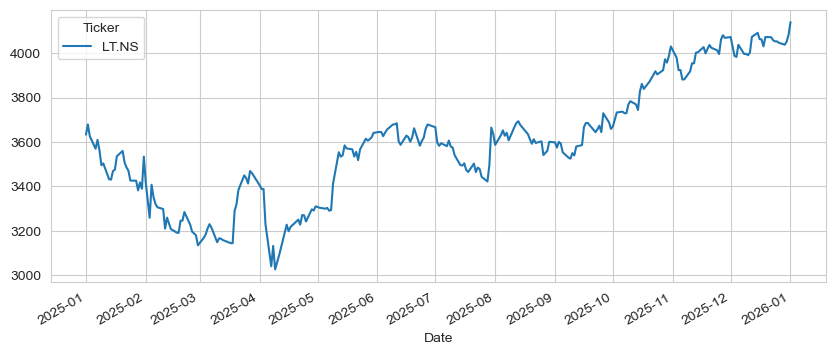

In [9]:
ax = stock_df['LT']['Close'].plot(legend = True, figsize = (10,4))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks = 45

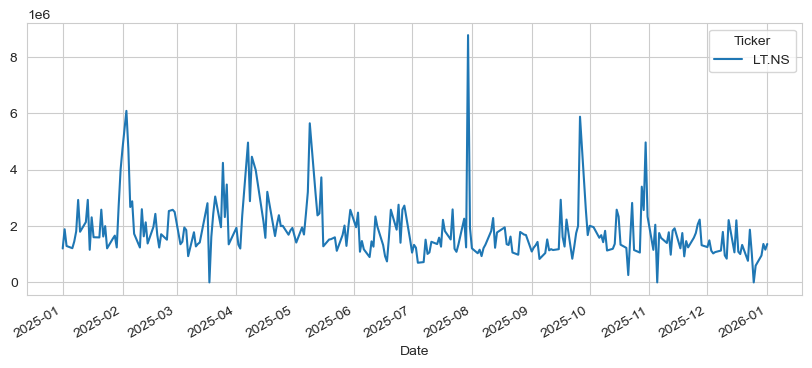

In [10]:
vx = stock_df['LT']['Volume'].plot(figsize = (10,4), legend = True)
vx.xaxis.set_major_locator(mdates.MonthLocator())

<h4>Finding moving average for a particular stock</h4>

In [17]:
ma_days = [10, 20, 30]
for stocks in nse_stocks:
    for ma in ma_days:
        column_name = "MA for %s days" %(str(ma)) 

        stock_df[stocks][column_name] = (stock_df[stocks]['Close'].rolling(window =  ma).mean())

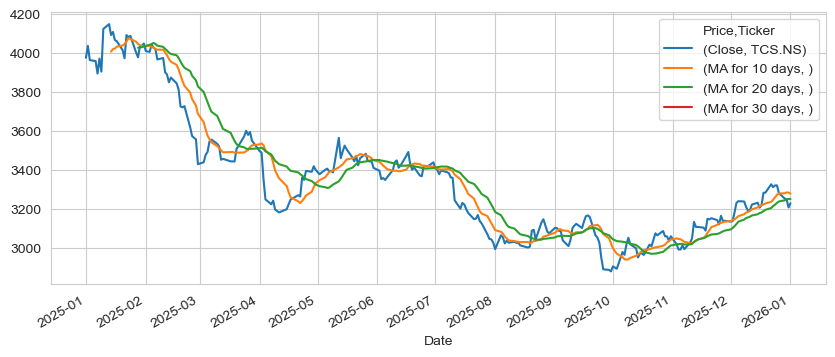

In [22]:
ma = stock_df['TCS'][['Close', 'MA for 10 days', 'MA for 20 days', 'MA for 30 days']].plot(subplots = False, figsize = (10,4))
ma.xaxis.set_major_locator(mdates.MonthLocator())

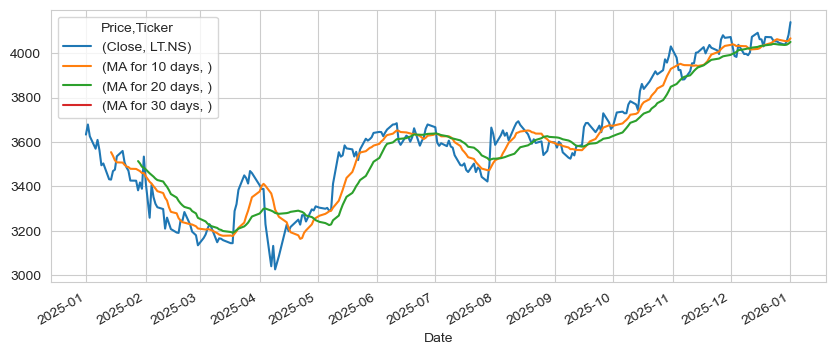

In [18]:
ma = stock_df['LT'][['Close', 'MA for 10 days', 'MA for 20 days', 'MA for 30 days']].plot(subplots = False, figsize = (10,4))
ma.xaxis.set_major_locator(mdates.MonthLocator())

<h4>To know the daily change for the stock</h4>

In [19]:
for stocks in nse_stocks:
    stock_df[stocks].loc[:,'daily_returns'] = stock_df[stocks]['Close'].pct_change()


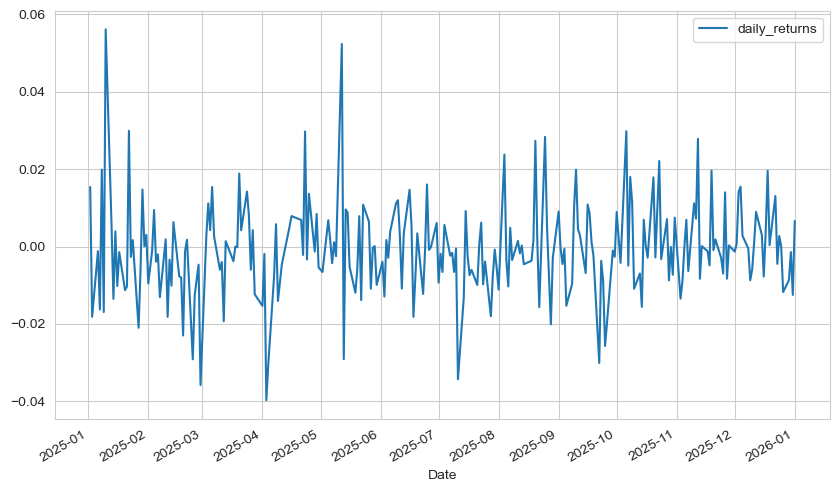

In [27]:
stock_df['TCS']['daily_returns'].plot(legend = True).xaxis.set_major_locator(mdates.MonthLocator())

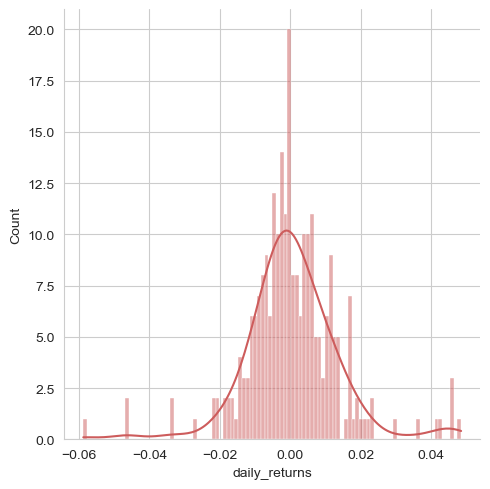

In [30]:
sns.displot(stock_df['LT']['daily_returns'].dropna(), bins = 100, color = 'indianred', kde = True)

<Axes: >

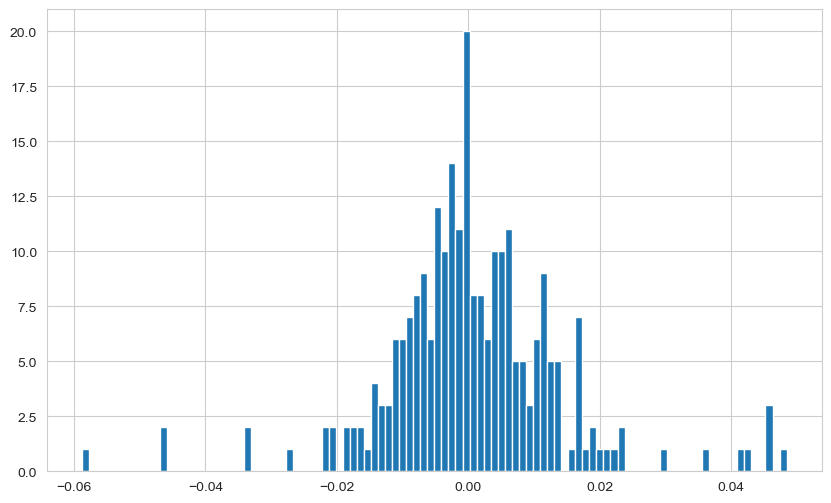

In [32]:
stock_df['LT']['daily_returns'].hist(bins = 100)

In [38]:
closing_df = yf.download([f'{stocks}.NS' for stocks in nse_stocks],start_date, end_date)['Close']

[*********************100%***********************]  6 of 6 completed


In [40]:
closing_df.head()

Ticker,HDFCBANK.NS,ICICIBANK.NS,LT.NS,RELIANCE.NS,TATAPOWER.NS,TCS.NS
Date,,,,,,
2025-01-01,879.486938,1273.821167,3633.611816,1216.391846,390.054382,3974.209473
2025-01-02,884.913635,1280.717896,3679.186768,1236.860107,393.185944,4035.381836
2025-01-03,862.935669,1255.363525,3626.081787,1246.172974,394.329193,3962.081299
2025-01-06,843.843811,1254.420776,3569.905762,1213.154785,376.434509,3957.345947
2025-01-07,845.274414,1269.454834,3609.635498,1235.913818,376.533936,3892.887939


In [42]:
tech_returns = closing_df.pct_change()

tech_returns.head()

Ticker,HDFCBANK.NS,ICICIBANK.NS,LT.NS,RELIANCE.NS,TATAPOWER.NS,TCS.NS
Date,,,,,,
2025-01-01,NaN,NaN,NaN,NaN,NaN,NaN
2025-01-02,0.006170,0.005414,0.012543,0.016827,0.008029,0.015392
2025-01-03,-0.024836,-0.019797,-0.014434,0.007529,0.002908,-0.018164
2025-01-06,-0.022124,-0.000751,-0.015492,-0.026496,-0.045380,-0.001195
2025-01-07,0.001695,0.011985,0.011129,0.018760,0.000264,-0.016288


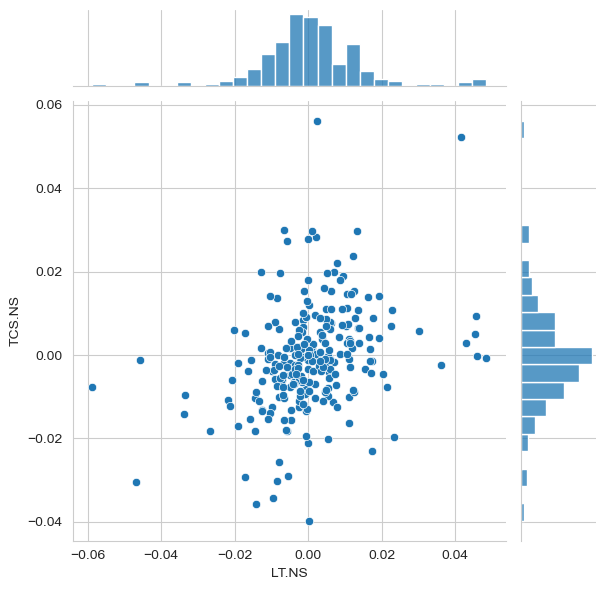

In [46]:
sns.jointplot(x = 'LT.NS', y = 'TCS.NS', data = tech_returns, kind = 'scatter')